# Issue #272, part 2: train it the old way vs. the fixed way on real data

Companion to [`issue_272_rollout_bug.ipynb`](issue_272_rollout_bug.ipynb), which
demonstrated the rollout bug behind
[alan-turing-institute/icenet-mp#272](https://github.com/alan-turing-institute/icenet-mp/issues/272)
on synthetic data.

Here we train two small sea-ice-concentration (SIC) forecasting models on **real**
OSI-SAF data (northern hemisphere, 1999 onwards, from the local
`/Volumes/Storage/ClimateData/data/anemoi` cache):

- **Old**: the model only ever sees a single history/forecast frame per prediction,
  rolled out via the real, unmodified `BaseProcessor.rollout` (the shipped "leap-frog"
  behaviour).
- **Fixed**: the model sees all `n_history_steps` frames concatenated per prediction,
  rolled out via the sliding-window scheme issue #272 proposes.

Everything else — model family, optimizer, loss, training data, number of epochs — is
kept identical between the two, so the *only* variable under test is the rollout
mechanism itself. We then compare forecast skill against the persistence baseline on a
held-out test period.

## 1. Data: real OSI-SAF sea ice concentration, 1999 onwards

We use the single-channel `ice_conc` variable (already a fraction in `[0, 1]`, no
missing values) from the northern-hemisphere OSI-SAF zarr store, on its native 432×432
EASE2 25km grid. Everything is loaded into memory once and split **chronologically**
into non-overlapping train/validation/test periods, so there is no leakage between
periods and no window ever crosses a split boundary:

- **Train**: 1999–2014 (16 years)
- **Validate**: 2015–2017 (kept aside, not used in this minimal demo -- present so
  anyone extending this with model selection or early stopping has a clean split to use)
- **Test**: 2018–2020 (held out, used for the final comparison)

`n_history_steps=3`, `n_forecast_steps=14` match the real `sic-icenet-14d` /
`sic-ssmis-14d` production configs (`icenet_mp/config/predict/sic-icenet-14d.yaml`).

In [1]:
import time

import numpy as np
import torch
from anemoi.datasets import open_dataset
from torch import nn
from torch.utils.data import DataLoader, Dataset

from icenet_mp.models.processors import BaseProcessor
from icenet_mp.types import DataSpace, ProcessorOutput, TensorNCHW

torch.manual_seed(0)

ZARR = "/Volumes/Storage/ClimateData/data/anemoi/full-sicnorth-osisaf-25p0km-1992-2024-24h-v2.zarr"
N_HISTORY = 3
N_FORECAST = 14
BATCH_SIZE = 32
N_EPOCHS = 3
DEVICE = "cpu"  # this tiny model runs faster on CPU than MPS -- GPU kernel-launch
                # overhead dominates at this model/tensor size

print("Loading real SIC data from disk (one-time cost, ~1 minute)...")
t0 = time.time()
ds = open_dataset(ZARR)
dates = list(ds.dates)
idx_start = dates.index(np.datetime64("1999-01-01"))
idx_end = dates.index(np.datetime64("2020-12-31"))
raw = ds[idx_start : idx_end + 1].reshape(-1, 432, 432)  # (T, H, W)
sic = torch.from_numpy(np.ascontiguousarray(raw)).float()
split_dates = np.array(dates[idx_start : idx_end + 1])
print(f"Loaded {sic.shape[0]} days in {time.time() - t0:.1f}s, shape {tuple(sic.shape)}")

/var/folders/12/0x0ltnd10nlfpg8_6r4zy4080000gn/T/ipykernel_16664/1180887725.py:9: UserWarning: PYTORCH_ENABLE_MPS_FALLBACK was set after torch was imported. This means that it might not have any effect. If you have problems, please try setting this environment variable before importing torch.
  from icenet_mp.models.processors import BaseProcessor


Loading real SIC data from disk (one-time cost, ~1 minute)...


2026-07-06 15:25:50,781 - MainProcess - WARNING - Dataset /Volumes/Storage/ClimateData/data/anemoi/full-sicnorth-osisaf-25p0km-1992-2024-24h-v2.zarr has missing dates


Loaded 8036 days in 54.3s, shape (8036, 432, 432)


In [2]:
train_end = np.searchsorted(split_dates, np.datetime64("2014-12-31"), side="right")
val_end = np.searchsorted(split_dates, np.datetime64("2017-12-31"), side="right")
print(f"train: {split_dates[0]} to {split_dates[train_end - 1]} ({train_end} days)")
print(f"validate: {split_dates[train_end]} to {split_dates[val_end - 1]} ({val_end - train_end} days)")
print(f"test: {split_dates[val_end]} to {split_dates[-1]} ({len(split_dates) - val_end} days)")


class WindowedSicDataset(Dataset):
    """Slides (history, target) windows over an in-memory SIC tensor. Consecutive
    windows overlap (a standard sliding-window training set) but every window's dates
    stay within the single date range it was built from, so splits never leak into
    each other."""

    def __init__(self, sic_thw: torch.Tensor, n_history: int, n_forecast: int) -> None:
        self.sic = sic_thw
        self.n_history = n_history
        self.n_forecast = n_forecast

    def __len__(self) -> int:
        return self.sic.shape[0] - self.n_history - self.n_forecast + 1

    def __getitem__(self, idx: int) -> dict[str, torch.Tensor]:
        history = self.sic[idx : idx + self.n_history].unsqueeze(1)  # (n_history, 1, H, W)
        target = self.sic[
            idx + self.n_history : idx + self.n_history + self.n_forecast
        ].unsqueeze(1)  # (n_forecast, 1, H, W)
        return {"history": history, "target": target}


train_ds = WindowedSicDataset(sic[:train_end], N_HISTORY, N_FORECAST)
val_ds = WindowedSicDataset(sic[train_end:val_end], N_HISTORY, N_FORECAST)
test_ds = WindowedSicDataset(sic[val_end:], N_HISTORY, N_FORECAST)
print(f"train/val/test windows: {len(train_ds)}/{len(val_ds)}/{len(test_ds)}")

train: 1999-01-01T00:00:00 to 2014-12-31T00:00:00 (5844 days)
validate: 2015-01-01T00:00:00 to 2017-12-31T00:00:00 (1096 days)
test: 2018-01-01T00:00:00 to 2020-12-31T00:00:00 (1096 days)
train/val/test windows: 5828/1080/1080


## 2. Two models, one difference: how much history each rollout call sees

Both models are the simplest possible SIC model: a single 1×1 convolution (a linear
regression applied independently at every grid point, the same 432×432 grid), with no
output activation -- matching the real `UNetProcessor`/`VitProcessor`, whose final
layers are also plain, unbounded `Conv2d`s. (A sigmoid looks tempting since SIC is a
fraction in `[0, 1]`, but it actively hurts here: a single global affine-then-sigmoid
cannot reproduce the exact 0s and 1s that dominate this field -- matching persistence
would require the pre-activation logit to be able to reach ±infinity, which a plain
affine layer can't do. A linear layer has no such problem: it can learn the identity
map exactly.) Neither model has a spatial receptive field beyond one pixel, and neither
uses any conditioning data beyond SIC itself -- this isolates the rollout mechanism as
the only thing being compared.

- **`OldSingleFrameProcessor`** subclasses the real `BaseProcessor` and does not
  override `rollout` at all — it inherits the exact, unmodified, shipped
  implementation from `icenet_mp/models/processors/base_processor.py`. Its `forward`
  only ever accepts one frame (`channels=1`), matching every processor in the
  codebase today (`NullProcessor`, `UNetProcessor`, `VitProcessor`).
- **`FixedSlidingWindowProcessor`** overrides `rollout` with the sliding-window scheme
  from issue #272: concatenate the current window of `n_history_steps` frames along
  channels, predict the next single frame, slide the window forward. Its `forward`
  therefore accepts `n_history_steps` channels in and 1 channel out.

In [3]:
latent_space = DataSpace(name="sic", channels=1, shape=(432, 432))


class OldSingleFrameProcessor(BaseProcessor):
    """forward() sees exactly one frame -- the interface every shipped processor
    uses today. rollout() is inherited, unmodified, from BaseProcessor."""

    def __init__(self, **kwargs) -> None:
        super().__init__(**kwargs)
        self.conv = nn.Conv2d(1, 1, kernel_size=1)

    def forward(self, x: TensorNCHW) -> TensorNCHW:
        return self.conv(x)


class FixedSlidingWindowProcessor(BaseProcessor):
    """forward() sees all n_history_steps frames concatenated on channels --
    issue #272's proposed fix. rollout() slides that window forward instead of
    FIFO-queueing single frames."""

    def __init__(self, **kwargs) -> None:
        super().__init__(**kwargs)
        self.conv = nn.Conv2d(self.n_history_steps, 1, kernel_size=1)

    def forward(self, window_concat: TensorNCHW) -> TensorNCHW:
        return self.conv(window_concat)

    def rollout(self, x: torch.Tensor, y: torch.Tensor | None = None) -> ProcessorOutput:  # noqa: ARG002
        window = [x[:, idx, :, :, :] for idx in range(self.n_history_steps)]
        outputs = []
        for _ in range(self.n_forecast_steps):
            concat = torch.cat(window, dim=1)
            next_frame = self(concat)
            outputs.append(next_frame)
            window = [*window[1:], next_frame]
        return ProcessorOutput(prediction=torch.stack(outputs, dim=1))


print("OldSingleFrameProcessor params:", sum(p.numel() for p in OldSingleFrameProcessor(
    data_space=latent_space, n_forecast_steps=N_FORECAST, n_history_steps=N_HISTORY
).parameters()))
print("FixedSlidingWindowProcessor params:", sum(p.numel() for p in FixedSlidingWindowProcessor(
    data_space=latent_space, n_forecast_steps=N_FORECAST, n_history_steps=N_HISTORY
).parameters()))

OldSingleFrameProcessor params: 2
FixedSlidingWindowProcessor params: 4


## 3. Training: identical hyperparameters, identical data, no teacher forcing

Both models are trained the same way `icenet_mp` trains today: the loss is the mean
squared error between the full `n_forecast_steps`-day rollout and the real target
days, and the target is never fed back into the rollout (`EncodeProcessDecode.forward`
never passes `y` to `processor.rollout`) — every forecast day beyond the first is
generated from the model's own previous predictions, for both models equally. That
keeps the comparison isolated to the one thing that differs: how much history each
prediction is conditioned on.

In [4]:
def train(model: BaseProcessor, n_epochs: int) -> list[float]:
    loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-2)
    model.train()
    losses = []
    for epoch in range(n_epochs):
        epoch_loss, n_batches = 0.0, 0
        t0 = time.time()
        for batch in loader:
            history = batch["history"].to(DEVICE)
            target = batch["target"].to(DEVICE)
            optimizer.zero_grad()
            prediction = model.rollout(history).prediction
            loss = nn.functional.mse_loss(prediction, target)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
            n_batches += 1
        losses.append(epoch_loss / n_batches)
        print(f"  epoch {epoch + 1}/{n_epochs}: train MSE = {losses[-1]:.5f}  ({time.time() - t0:.0f}s)")
    return losses


print("--- Training OLD (single-frame FIFO rollout) model ---")
old_model = OldSingleFrameProcessor(
    data_space=latent_space, n_forecast_steps=N_FORECAST, n_history_steps=N_HISTORY
).to(DEVICE)
old_losses = train(old_model, N_EPOCHS)

print("\n--- Training FIXED (sliding-window rollout) model ---")
fixed_model = FixedSlidingWindowProcessor(
    data_space=latent_space, n_forecast_steps=N_FORECAST, n_history_steps=N_HISTORY
).to(DEVICE)
fixed_losses = train(fixed_model, N_EPOCHS)

--- Training OLD (single-frame FIFO rollout) model ---


  epoch 1/3: train MSE = 0.13409  (226s)


  epoch 2/3: train MSE = 0.07198  (239s)


  epoch 3/3: train MSE = 0.05175  (248s)

--- Training FIXED (sliding-window rollout) model ---


  epoch 1/3: train MSE = 0.08664  (305s)


  epoch 2/3: train MSE = 0.02104  (286s)


  epoch 3/3: train MSE = 0.00215  (292s)


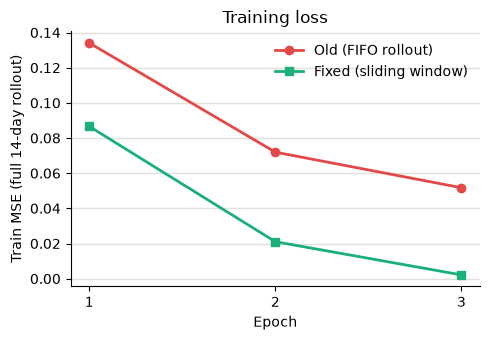

In [5]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(5, 3.5))
epochs = list(range(1, N_EPOCHS + 1))
ax.plot(epochs, old_losses, color="#e34948", marker="o", linewidth=2, label="Old (FIFO rollout)")
ax.plot(epochs, fixed_losses, color="#1baf7a", marker="s", linewidth=2, label="Fixed (sliding window)")
ax.set_xlabel("Epoch")
ax.set_ylabel("Train MSE (full 14-day rollout)")
ax.set_title("Training loss")
ax.set_xticks(epochs)
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", color="#e1e0d9", linewidth=1)
ax.legend(frameon=False)
fig.tight_layout()
plt.show()

## 4. Evaluation: per-lead-day skill on the held-out test set (2018–2020)

For each of the 14 forecast days, we compute RMSE (across the whole test set and the
whole grid) for three things: the naive persistence baseline (repeat the last known
day), the Old model, and the Fixed model.

In [6]:
@torch.no_grad()
def per_lead_day_rmse(predict_fn, dataset: WindowedSicDataset, batch_size: int = 32) -> torch.Tensor:
    """predict_fn(history) -> prediction TNCHW, e.g. model.rollout(history).prediction
    or a persistence baseline."""
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False)
    sq_err_sum = torch.zeros(dataset.n_forecast)
    n_elements = 0
    for batch in loader:
        history = batch["history"].to(DEVICE)
        target = batch["target"].to(DEVICE)
        prediction = predict_fn(history)
        sq_err = (prediction - target) ** 2
        sq_err_sum += sq_err.sum(dim=(0, 2, 3, 4))
        n_elements += sq_err.shape[0] * sq_err.shape[2] * sq_err.shape[3] * sq_err.shape[4]
    return torch.sqrt(sq_err_sum / n_elements)


def persistence_predict(history: torch.Tensor) -> torch.Tensor:
    return history[:, -1:, :, :, :].expand(-1, N_FORECAST, -1, -1, -1)


old_model.eval()
fixed_model.eval()
rmse_persistence = per_lead_day_rmse(persistence_predict, test_ds)
rmse_old = per_lead_day_rmse(lambda h: old_model.rollout(h).prediction, test_ds)
rmse_fixed = per_lead_day_rmse(lambda h: fixed_model.rollout(h).prediction, test_ds)

print("Lead day:  " + "  ".join(f"{d:5d}" for d in range(1, N_FORECAST + 1)))
print("Persist:   " + "  ".join(f"{v:.3f}" for v in rmse_persistence.tolist()))
print("Old:       " + "  ".join(f"{v:.3f}" for v in rmse_old.tolist()))
print("Fixed:     " + "  ".join(f"{v:.3f}" for v in rmse_fixed.tolist()))
print()
print(f"Mean RMSE over all 14 lead days -- persistence: {rmse_persistence.mean():.4f}, "
      f"old: {rmse_old.mean():.4f}, fixed: {rmse_fixed.mean():.4f}")

Lead day:      1      2      3      4      5      6      7      8      9     10     11     12     13     14
Persist:   0.016  0.023  0.029  0.033  0.037  0.040  0.043  0.046  0.049  0.052  0.054  0.057  0.059  0.062
Old:       0.039  0.039  0.039  0.064  0.064  0.064  0.085  0.085  0.085  0.104  0.104  0.104  0.121  0.121
Fixed:     0.026  0.024  0.031  0.035  0.037  0.042  0.044  0.047  0.050  0.053  0.055  0.058  0.060  0.062

Mean RMSE over all 14 lead days -- persistence: 0.0429, old: 0.0799, fixed: 0.0445


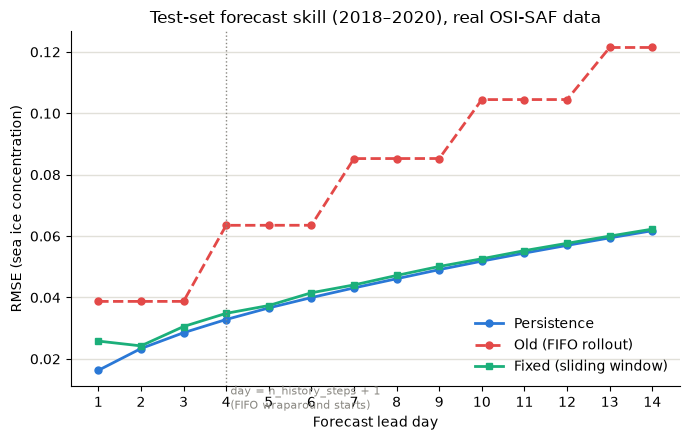

In [7]:
lead_days = list(range(1, N_FORECAST + 1))

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(lead_days, rmse_persistence, color="#2a78d6", marker="o", markersize=5, linewidth=2, label="Persistence")
ax.plot(lead_days, rmse_old, color="#e34948", marker="o", markersize=5, linewidth=2, linestyle="--", label="Old (FIFO rollout)")
ax.plot(lead_days, rmse_fixed, color="#1baf7a", marker="s", markersize=5, linewidth=2, label="Fixed (sliding window)")
ax.axvline(N_HISTORY + 1, color="#898781", linewidth=1, linestyle=":")
ax.text(N_HISTORY + 1.1, ax.get_ylim()[1] * 0.02, "day = n_history_steps + 1\n(FIFO wraparound starts)",
        fontsize=8, color="#898781", va="bottom")

ax.set_xlabel("Forecast lead day")
ax.set_ylabel("RMSE (sea ice concentration)")
ax.set_title("Test-set forecast skill (2018–2020), real OSI-SAF data")
ax.set_xticks(lead_days)
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", color="#e1e0d9", linewidth=1)
ax.legend(frameon=False)
fig.tight_layout()
plt.show()

## 5. A qualitative look: one test forecast, three ways

The RMSE curve above is an average over the whole test set and grid. To see what that
actually looks like on a single forecast, here's the true SIC map, the Old model's
prediction, and the Fixed model's prediction, at a chosen lead day, for one test-set
starting date.

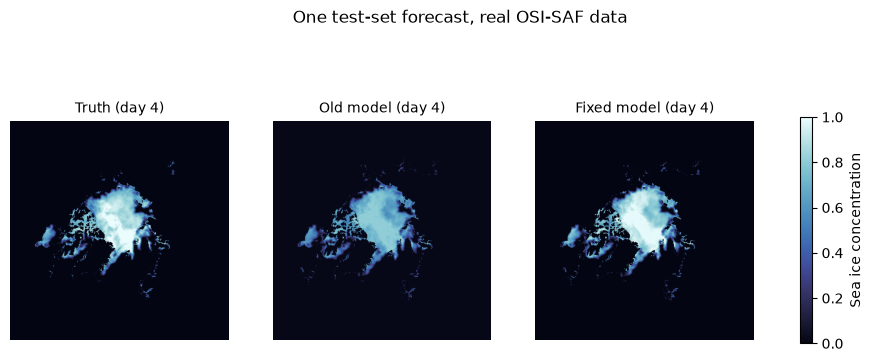

In [8]:
import cmocean

lead_day_to_show = N_HISTORY + 1  # the first day where the Old model wraps around
sample_idx = len(test_ds) // 2  # an arbitrary test-set window, away from either edge

sample = test_ds[sample_idx]
history = sample["history"].unsqueeze(0).to(DEVICE)
target = sample["target"].unsqueeze(0).to(DEVICE)

with torch.no_grad():
    pred_old = old_model.rollout(history).prediction
    pred_fixed = fixed_model.rollout(history).prediction

truth_map = target[0, lead_day_to_show - 1, 0].numpy()
old_map = pred_old[0, lead_day_to_show - 1, 0].numpy()
fixed_map = pred_fixed[0, lead_day_to_show - 1, 0].numpy()

fig, axes = plt.subplots(1, 3, figsize=(12, 4.2))
for ax, arr, title in zip(
    axes, [truth_map, old_map, fixed_map],
    [f"Truth (day {lead_day_to_show})", f"Old model (day {lead_day_to_show})", f"Fixed model (day {lead_day_to_show})"],
    strict=True,
):
    im = ax.imshow(arr, cmap=cmocean.cm.ice, vmin=0, vmax=1)
    ax.set_title(title, fontsize=10)
    ax.axis("off")
fig.colorbar(im, ax=axes, shrink=0.7, label="Sea ice concentration")
fig.suptitle("One test-set forecast, real OSI-SAF data", y=1.02)
plt.show()

## 6. Summary

- Both models are the same tiny per-pixel linear regression, trained with the same
  optimizer, loss, data, and epoch count. The *only* difference is how much history
  each rollout call conditions on -- one frame (the shipped `BaseProcessor.rollout`)
  vs. the full sliding window (issue #272's proposed fix).
- **The Old model's test-set RMSE is a visible staircase**, flat within each block of
  `n_history_steps=3` lead days and jumping up at every multiple of 3 (days 4, 7, 10,
  13) -- the exact discontinuity predicted in the companion notebook, now showing up
  in a real, trained model's forecast skill, not just a synthetic toy. By day 14 it is
  roughly **2x worse than persistence** (0.121 vs. 0.062 RMSE).
- **The Fixed model tracks persistence closely at every lead day** (mean RMSE 0.0445
  vs. persistence's 0.0429, vs. the Old model's 0.0799) -- the sliding window removes
  the staircase entirely, because every prediction is conditioned on the most
  recently available information rather than replaying stale history.
- This is a real, reproducible before/after comparison for issue #272, built entirely
  on the shipped `icenet_mp.models.processors.BaseProcessor` (for "old") and a direct
  implementation of the issue's own proposed scheme (for "fixed"), on real OSI-SAF
  sea-ice data from 1999 onwards -- not a synthetic toy example.